In [1]:
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import os
import random

In [2]:
path = "../dataset/"

In [3]:
saines = [os.path.join(f"{path}/Saines", f) for f in os.listdir(f"{path}/Saines")]
malades = [os.path.join(f"{path}/Malades", f) for f in os.listdir(f"{path}/Malades")]

In [4]:
def afficherImage(images1, images2):
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))

    for i in range(5):
        axes[0, i].imshow(images1[i])
        axes[0, i].axis("off")
        axes[0, i].set_title("Saines")
    
    for i in range(5):
        axes[1, i].imshow(images2[i])
        axes[1, i].axis("off")
        axes[1, i].set_title("Malades")
    
    plt.tight_layout()
    plt.show()

### Nombre d'image pour chaque catégorie

In [5]:
print(f"Image Plante saine : {len(saines)}, Image Plante malade {len(malades)}")

Image Plante saine : 1162, Image Plante malade 1657


In [6]:
saines_img = [cv2.imread(img) for img in saines]
malades_img = [cv2.imread(img)for img in malades]

### Visualisation de quelque images du dataset

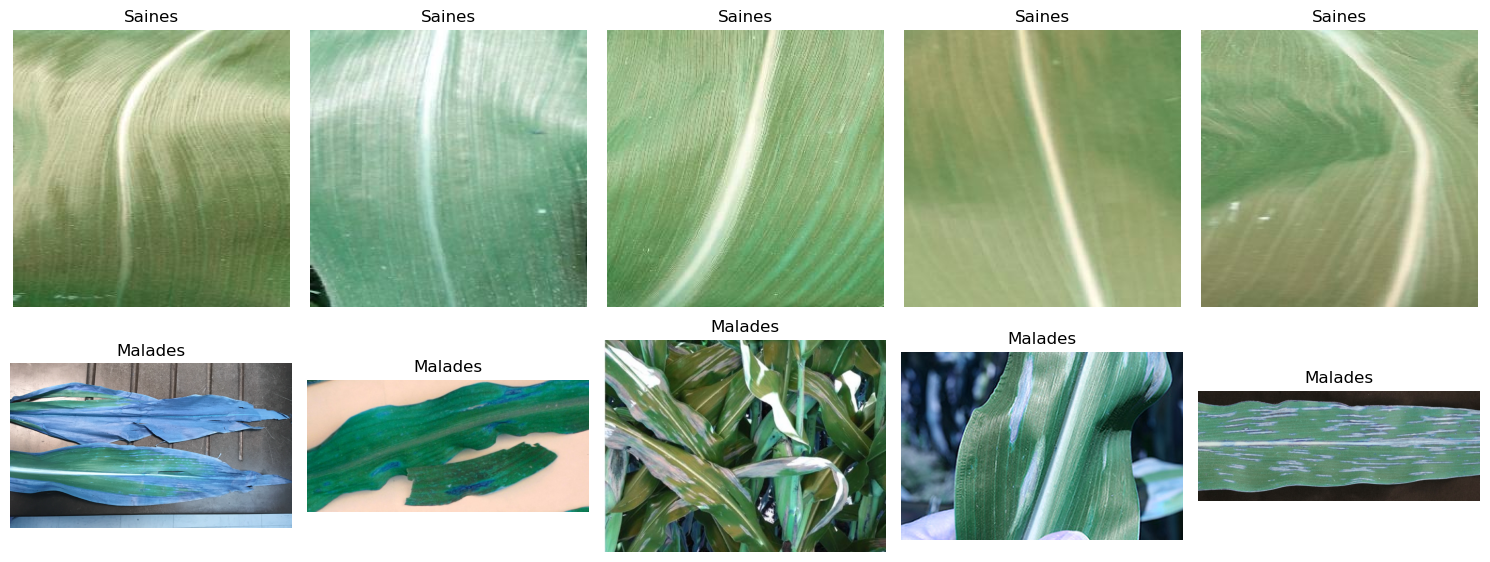

In [7]:
afficherImage(saines_img, malades_img)

### Isolement des couleurs indépendamment des variations de luminosité

In [8]:
saines_img_hsv = [cv2.cvtColor(img, cv2.COLOR_BGR2HSV) for img in saines_img]
malades_img_hsv = [cv2.cvtColor(img, cv2.COLOR_BGR2HSV) for img in malades_img]

### Visualisation des images modifiés

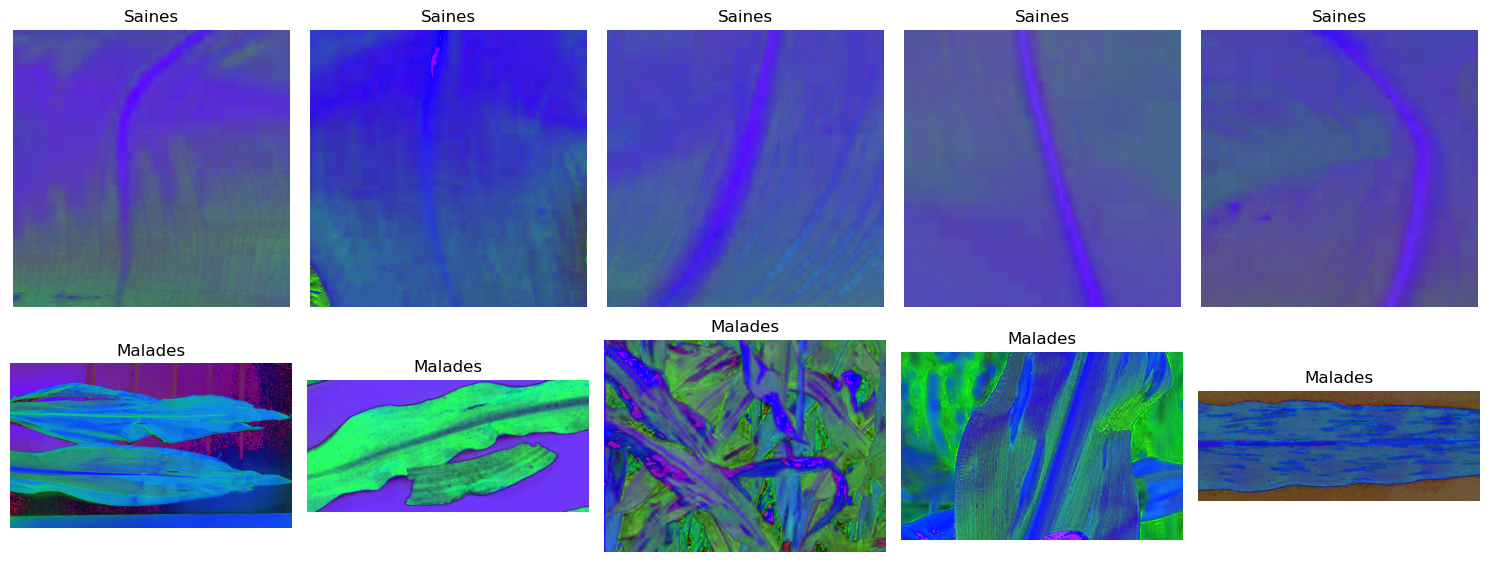

In [9]:
afficherImage(saines_img_hsv, malades_img_hsv)

### Masque de couleur

In [10]:
lower_rouille = np.array([10, 50, 50])   # orange/marron foncé
upper_rouille = np.array([30, 255, 255])  # jaune/orange

In [11]:
saines_img_HSVmask = [cv2.inRange(img, lower_rouille, upper_rouille) for img in saines_img_hsv]
malades_img_HSVmask = [cv2.inRange(img, lower_rouille, upper_rouille) for img in malades_img_hsv]

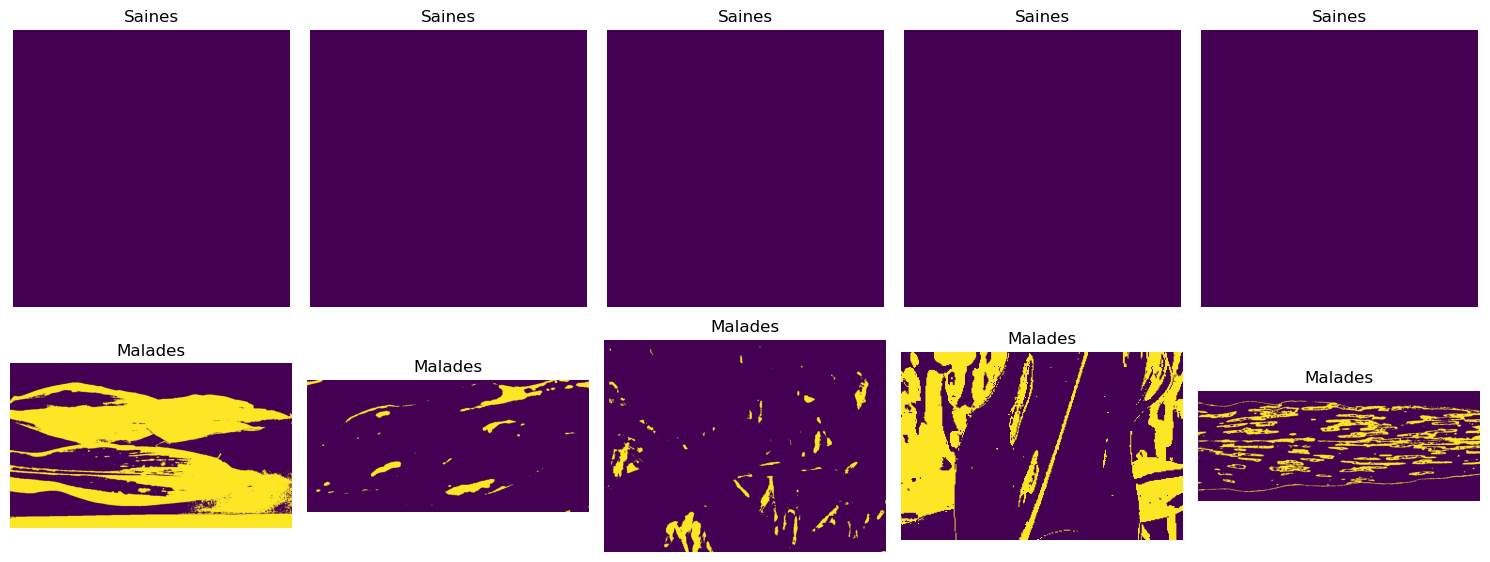

In [12]:
afficherImage(saines_img_HSVmask, malades_img_HSVmask)

### Caractéristiques rouille de la feuille pct_rouille  (après le mask, pixel->255: rouille 0: non_rouille)

In [13]:
def pct_rouille(mask):
    nb_rouille = np.count_nonzero(mask)
    nb_non_rouille = np.sum(mask == 0)
    return nb_rouille / nb_non_rouille

In [14]:
saines_pctRouille = [pct_rouille(mask) for mask in saines_img_HSVmask]
malades_pctRouille = [pct_rouille(mask) for mask in malades_img_HSVmask]

### Extraction de texture et rugosité (Filtre de Sobel) 

**Sobel():** calcul la variation de l'image 
Sobel(couleur, type de donnée de sortie, direction de calcul "dérivée en X si 1 sinon pas en X", direction de calcul "dérien en y si 1 sinon pas en y", taille du filtre)

In [15]:
def sobel_img(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)  #calcule la variation de l’image (couleur, type de donnée de sortie, direction de calcul)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

    sobel = cv2.magnitude(sobel_x, sobel_y) # Combinaison des 2
    del gray, sobel_x, sobel_y
    return sobel

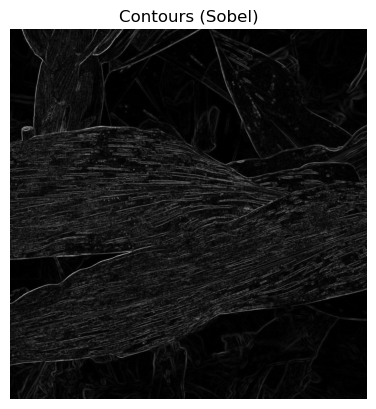

In [16]:
plt.imshow(sobel_img(malades_img[12]), cmap="gray")
plt.title("Contours (Sobel)")
plt.axis("off")
plt.show()

In [17]:
def variance_sobel(img):
    sobel = sobel_img(img)
    return np.var(sobel)

In [18]:
saines_varSobel = [variance_sobel(img) for img in saines_img]
malades_varSobel = [variance_sobel(img) for img in malades_img]

## Délimitation par nervure

In [19]:
def est_delimite_par_nervures(img):
    gray = gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0) # Prétraitement (Flou pour réduire le bruit)
    # 3. Seuillage (Thresholding) pour isoler les lésions sombres/nécrosées
    # Note : Ajustez la valeur (ici 100) selon la luminosité des images
    _, thresh = cv2.threshold(blurred, 100, 255, cv2.THRESH_BINARY_INV)
    
    # 4. Trouver les contours des lésions
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return 0 # Aucune lésion détectée
        
    # On prend le plus grand contour (souvent la lésion principale)
    largest_contour = max(contours, key=cv2.contourArea)
    
    # 5. Obtenir la "Bounding Box" droite (Bounding Rect) et orientée (Min Area Rect)
    x, y, w, h = cv2.boundingRect(largest_contour)
    
    # Calcul de la rectangularité (rapport entre l'aire du contour et l'aire de sa boîte)
    contour_area = cv2.contourArea(largest_contour)
    bounding_box_area = w * h
    
    if bounding_box_area == 0:
        return 0
        
    solidity = contour_area / float(bounding_box_area)
    aspect_ratio = float(h) / w if w > 0 else 0
    
    # 6. Condition de retour (Logique de décision)
    # Pour la Cercosporiose (Image 1) :
    # - La lésion est très allongée verticalement (aspect_ratio élevé)
    # - Elle remplit bien sa boîte rectangulaire car ses bords sont droits (solidity élevée)
    
    if aspect_ratio > 2.5 and solidity > 0.70:
        return 1  # La lésion est rectangulaire et suit les nervures
    else:
        return 0  # La lésion déborde (ovale, fuseau ou irrégulière)

In [20]:
saines_nervure = [est_delimite_par_nervures(img) for img in saines_img]
maladies_nervure = [est_delimite_par_nervures(img) for img in malades_img]

## Resultat maladie

In [33]:
saines_statut = [int(0) for img in saines]
malades_statut = [int(1) for img in malades]

# Exportation en csv

In [34]:
total_data = saines + malades

In [35]:
Id_image = [int(i+1) for i in range(len(total_data))]
pct_rouille = saines_pctRouille+malades_pctRouille
rugosite = saines_varSobel + malades_varSobel
nervure = saines_nervure + maladies_nervure
etat_plante = saines_statut + malades_statut

In [36]:
data = [pct_rouille, rugosite, nervure, etat_plante]
columns = ["pct_rouille", "rugosite", "nervure", "est_malade"]

In [37]:
# random.seed(42)
# random.shuffle(data)

In [38]:
df = pd.DataFrame(data)
df = df.T #transposena satria lasa @column ndray le ligne
df.columns = columns

In [39]:
df.head()

,pct_rouille,rugosite,nervure,est_malade
0,0.0,733.206356,0.0,0.0
1,0.0,879.171051,0.0,0.0
2,0.0,987.782414,0.0,0.0
3,0.0,265.555601,0.0,0.0
4,0.0,432.487942,0.0,0.0


In [40]:
df.tail()

,pct_rouille,rugosite,nervure,est_malade
2814,0.276037,5422.757653,0.0,1.0
2815,0.081541,6415.231673,0.0,1.0
2816,0.481508,8622.066607,0.0,1.0
2817,0.268995,2221.433728,0.0,1.0
2818,0.143635,5420.358734,0.0,1.0


In [41]:
df.to_csv("../data/data.csv", sep=";", index=False)

In [42]:
df.groupby("est_malade").mean()

,pct_rouille,rugosite,nervure
est_malade,,,
0.0,0.000826,1781.767783,0.005164
1.0,0.229536,4860.939013,0.013881
